In [2]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [4]:
dataset = load_dataset("emotion")
print("Размеры split-ов:")
for split in dataset:
    print(f"{split}: {len(dataset[split])}")

Размеры split-ов:
train: 16000
validation: 2000
test: 2000


In [5]:
label_names = dataset["train"].features["label"].names
print("\nКлассы (6 эмоций):", label_names)
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}


Классы (6 эмоций): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [6]:
print("\nПримеры текстов и меток:")
for i in range(5):
    text = dataset["train"][i]["text"]
    label = label_names[dataset["train"][i]["label"]]
    print(f"{i+1}. {text[:80]}... -> {label}")


Примеры текстов и меток:
1. i didnt feel humiliated... -> sadness
2. i can go from feeling so hopeless to so damned hopeful just from being around so... -> sadness
3. im grabbing a minute to post i feel greedy wrong... -> anger
4. i am ever feeling nostalgic about the fireplace i will know that it is still on ... -> love
5. i am feeling grouchy... -> anger


In [7]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def show_tokenization(texts, tokenizer):
    rows = []
    for text in texts:
        tokens = tokenizer.tokenize(text)
        input_ids = tokenizer.encode(text, add_special_tokens=False)
        decoded = [tokenizer.decode([tid]) for tid in input_ids]
        rows.append({
            "text": text[:60] + "...",
            "tokens": tokens,
            "input_ids": input_ids,
            "decoded_pieces": decoded,
        })
    return pd.DataFrame(rows)

sample_texts = [dataset["train"][i]["text"] for i in range(5)]
display(show_tokenization(sample_texts, tokenizer))

short = "I am happy."
long = "This is a very long sentence that definitely exceeds the maximum length limit that we set for demonstration purposes."
encoded = tokenizer([short, long], padding=True, truncation=True, max_length=10, return_tensors="pt")
print("Padding и truncation (max_length=10):")
print("input_ids shape:", encoded["input_ids"].shape)
print("attention_mask:\n", encoded["attention_mask"])
print("Декодированные последовательности:")
for i in range(2):
    print(f"  {i}: {tokenizer.decode(encoded['input_ids'][i])}")

,text,tokens,input_ids,decoded_pieces
0,i didnt feel humiliated...,"[i, didn, ##t, feel, humiliated]","[1045, 2134, 2102, 2514, 26608]","[i, didn, ##t, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ...","[1045, 2064, 2175, 2013, 3110, 2061, 20625, 20...","[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wro...,"[im, grabbing, a, minute, to, post, i, feel, g...","[10047, 9775, 1037, 3371, 2000, 2695, 1045, 25...","[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nos, ##tal, ##gic, abou...","[1045, 2572, 2412, 3110, 16839, 9080, 12863, 2...","[i, am, ever, feeling, nos, ##tal, ##gic, abou..."
4,i am feeling grouchy...,"[i, am, feeling, gr, ##ou, ##chy]","[1045, 2572, 3110, 24665, 7140, 11714]","[i, am, feeling, gr, ##ou, ##chy]"


Padding и truncation (max_length=10):
input_ids shape: torch.Size([2, 10])
attention_mask:
 tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
Декодированные последовательности:
  0: [CLS] i am happy. [SEP] [PAD] [PAD] [PAD] [PAD]
  1: [CLS] this is a very long sentence that definitely [SEP]


In [8]:
pretrained_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

def predict_random(texts, model, tokenizer):
    enc = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=64)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=1)
    return [{"text": t, "pred_label": id2label[p], "confidence": float(probs[i][p])} for i, (t, p) in enumerate(zip(texts, preds))]

test_texts = [dataset["test"][i]["text"] for i in range(5)]
results = predict_random(test_texts, pretrained_model, tokenizer)
df_random = pd.DataFrame(results)
print("Предсказания модели без дообучения (случайная голова):")
display(df_random)
print("Готовая модель совершенно не подходит для задачи классификации эмоций, так как её голова не обучена.\nНеобходим fine‑tuning.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Предсказания модели без дообучения (случайная голова):


,text,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,anger,0.273731
1,im updating my blog because i feel shitty,anger,0.252022
2,i never make her separate from me because i do...,joy,0.198240
3,i left with my bouquet of red and yellow tulip...,anger,0.269020
4,i was feeling a little vain when i did this one,anger,0.191403


Готовая модель совершенно не подходит для задачи классификации эмоций, так как её голова не обучена.
Необходим fine‑tuning.


In [10]:
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=64)

tokenized_dataset = dataset.map(tokenize_fn, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

data_collator = DataCollatorWithPadding(tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results_emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=1,
    report_to="none",
)

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

test_metrics = trainer.evaluate(tokenized_dataset["test"])
print("Метрики на test после fine‑tuning:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\varva\AppData\Local\Programs

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.212675,0.205333,0.927500,0.905853
2,0.121917,0.177606,0.935500,0.911612
3,0.078382,0.162770,0.939500,0.915176


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

RuntimeError: on_train_begin must be called before on_evaluate

In [12]:
test_pred = trainer.predict(tokenized_dataset["test"])
logits = test_pred.predictions
true_labels = test_pred.label_ids
pred_labels = np.argmax(logits, axis=-1)

acc = accuracy_score(true_labels, pred_labels)
f1_macro = f1_score(true_labels, pred_labels, average="macro")
print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1_macro:.4f}")

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.9245
F1 macro: 0.8776


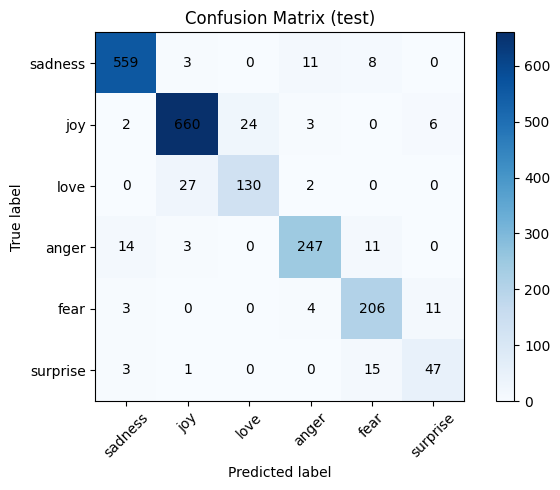

In [13]:
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(7,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (test)")
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45)
plt.yticks(tick_marks, label_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

In [15]:
test_texts_original = dataset["test"]["text"]
sample_indices = np.random.choice(len(test_texts_original), 10, replace=False)
sample_data = []
for idx in sample_indices:
    text = test_texts_original[idx]
    true = label_names[true_labels[idx]]
    pred = label_names[pred_labels[idx]]
    conf = float(torch.max(torch.softmax(torch.tensor(logits[idx]), dim=-1)).item())
    sample_data.append({"text": text, "true_label": true, "pred_label": pred, "confidence": conf})

df_samples = pd.DataFrame(sample_data)
display(df_samples)

df_samples.to_csv("artifacts/sample_predictions.csv", index=False)

,text,true_label,pred_label,confidence
0,i look over and to my utter horror i see a man...,fear,fear,0.998061
1,i feel like i m going to struggle and fail and...,sadness,sadness,0.999104
2,i wish i could do that chinese bite on my fing...,love,love,0.843853
3,i feel betrayed and angry and sad at the same ...,anger,sadness,0.774690
4,i feel so boring all the time,sadness,sadness,0.998977
5,i think they have always been proponents of th...,joy,joy,0.999254
6,i feel a lot of affection for you that is long...,love,love,0.996734
7,i feel for folks with tender plantings that ma...,love,love,0.996617
8,i feel like my mind is blank and empty,sadness,sadness,0.999107
9,i feel so relieved and happy to realize what i...,joy,joy,0.999250


In [16]:
errors = df_samples[df_samples["true_label"] != df_samples["pred_label"]]
print(f"Из 10 показанных примеров ошибок: {len(errors)}")
if len(errors) > 0:
    print("Примеры ошибок:")
    for _, row in errors.iterrows():
        print(f"  Текст: {row['text'][:70]}... -> true: {row['true_label']}, pred: {row['pred_label']}")
print("\nНаиболее частые ошибки (судя по матрице): путаница между 'fear' и 'sadness', 'anger' и 'fear', 'love' и 'joy'.")
print("Модель иногда ошибается в близких по смыслу эмоциях, что естественно для такой задачи.")

Из 10 показанных примеров ошибок: 1
Примеры ошибок:
  Текст: i feel betrayed and angry and sad at the same time dammit... -> true: anger, pred: sadness

Наиболее частые ошибки (судя по матрице): путаница между 'fear' и 'sadness', 'anger' и 'fear', 'love' и 'joy'.
Модель иногда ошибается в близких по смыслу эмоциях, что естественно для такой задачи.
